Starting with the EDA (exploratory Data Analysis) and cleaning, we need to load the dataset and identify possible missing values and wrong classes of data accordingly to the description of each one. The features description could be seeing bellow:

1. Cycle: Sequential identifier of measurement Cycles.
2. Preset_1 & Preset_2: Variables that control a specific operating point of the machine.
3. Temperature: Temperature recorded in the equipment.
4. Vibrations (X, Y & Z): Vibrations along the machine's axes.
5. Frequency: Operating frequency of the machine.
6. Fail: Variable indicating whether the machine is in a Failure state at the given timestamp.

In [280]:
import openpyxl
import pandas as pd
import scipy
from skimpy import skim
import matplotlib.pyplot as plt
import seaborn as sns
import logging  
import numpy as np
import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

import xgboost

d_raw = pd.read_excel('C:/Projects/SHAPE/data/raw/Test O_G_Equipment_Data.xlsx')

print(d_raw.head())

   Cycle  Preset_1  Preset_2  Temperature    Pressure  VibrationX  VibrationY  \
0      1         3         6    44.235186   47.657254   46.441769   64.820327   
1      2         2         4    60.807234   63.172076   62.005951   80.714431   
2      3         2         1    79.027536   83.032190   82.642110   98.254386   
3      4         2         3    79.716242  100.508634  122.362321  121.363429   
4      5         2         5    39.989054   51.764833   42.514302   61.037910   

   VibrationZ  Frequency   Fail  
0   66.454520  44.483250  False  
1   81.246405  60.228715  False  
2   98.785196  80.993479  False  
3  118.652538  80.315567  False  
4   50.716469  64.245166  False  


In [281]:
desc = d_raw.describe(include="all").T

desc["dtype"] = d_raw.dtypes.astype(str)
desc["missing"] = d_raw.isna().sum()
desc["missing_pct"] = (d_raw.isna().mean() * 100).round(2)
desc["n_unique"] = d_raw.nunique()

desc

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,dtype,missing,missing_pct,n_unique
Cycle,800.0,NaN,NaN,NaN,400.5,231.0844,1.0,200.75,400.5,600.25,800.0,int64,0,0.0,800
Preset_1,800.0,NaN,NaN,NaN,1.98875,0.805875,1.0,1.0,2.0,3.0,3.0,int64,0,0.0,3
Preset_2,800.0,NaN,NaN,NaN,4.55125,2.293239,1.0,3.0,5.0,7.0,8.0,int64,0,0.0,8
Temperature,800.0,NaN,NaN,NaN,69.263494,25.536252,2.089354,51.040134,65.906716,80.52722,255.607829,float64,0,0.0,800
Pressure,800.0,NaN,NaN,NaN,78.997945,32.501834,3.480279,55.508564,75.014848,99.30253,189.995681,float64,0,0.0,800
VibrationX,800.0,NaN,NaN,NaN,73.860275,31.229631,3.846343,50.752461,69.394953,90.195059,230.861142,float64,0,0.0,800
VibrationY,800.0,NaN,NaN,NaN,72.786878,32.739745,10.057744,48.523982,65.50477,94.075572,193.569947,float64,0,0.0,800
VibrationZ,800.0,NaN,NaN,NaN,71.866211,27.844616,18.784169,50.787638,69.319237,88.891205,230.951134,float64,0,0.0,800
Frequency,800.0,NaN,NaN,NaN,68.223449,29.138702,4.380101,45.861762,65.664252,90.097457,178.090303,float64,0,0.0,800
Fail,800,2,False,734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bool,0,0.0,2


In [282]:
# Changing the dtype of a column to string
d_raw["Cycle"] = d_raw["Cycle"].apply(lambda x: f"{int(x):03d}")
d_raw["Preset_1"] = d_raw["Preset_1"].astype(str)
d_raw["Preset_2"] = d_raw["Preset_2"].astype(str)
d_raw["Fail_cat"] = (
    d_raw["Fail"]
    .map({False: "No Failure", True: "Failure"})
    .astype("category")
)
d_raw["Fail_bin"] = (
    d_raw["Fail"]
    .map({False: 0, True: 1})
    .astype("int")
)


In [283]:

skim(d_raw)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 800    │ │ float64     │ 6     │ │ Fail_cat              │                                │
│ │ Number of columns │ 12     │ │ string      │ 3     │ └───────────────────────┘                                │
│ └───────────────────┴────────┘ │ bool        │ 1     │                                                          │
│                                │ category    │ 1     │                                                          │
│                                │ int64       │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column         ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │ Temperature    │   0 │      0 │    69.26 │    25.54 │  2.089 │  51.04 │  65.91 │  80.53 │  255.6 │   ▂▇▂   │  │
│ │ Pressure       │   0 │      0 │       79 │     32.5 │   3.48 │  55.51 │  75.01 │   99.3 │    190 │  ▁▇▇▅▁  │  │
│ │ VibrationX     │   0 │      0 │    73.86 │    31.23 │  3.846 │  50.75 │  69.39 │   90.2 │  230.9 │  ▂▇▅▁   │  │
│ │ VibrationY     │   0 │      0 │    72.79 │    32.74 │  10.06 │  48.52 │   65.5 │  94.08 │  193.6 │  ▃▇▅▃▁  │  │
│ │ VibrationZ     │   0 │      0 │    71.87 │    27.84 │  18.78 │  50.79 │  69.32 │  88.89 │    231 │  ▅▇▃▁   │  │
│ │ Frequency      │   0 │      0 │    68.22 │    29.14 │   4.38 │  45.86 │  65.66 │   90.1 │  178.1 │  ▃▇▇▅▁  │  │
│ │ Fail_bin       │   0 │      0 │   0.0825 │   0.2753 │      0 │      0 │      0 │      0 │      1 │ ▇    ▁  │  │
│ └────────────────┴─────┴────────┴──────────┴──────────┴────────┴────────┴────────┴────────┴────────┴─────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                      ┃ NA         ┃ NA %            ┃ ordered                 ┃ unique              ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Fail_cat                    │          0 │               0 │ False                   │                   2 │  │
│ └─────────────────────────────┴────────────┴─────────────────┴─────────────────────────┴─────────────────────┘  │
│                                                      bool                                                       │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                   ┃ true              ┃ true rate                         ┃ hist                    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Fail                     │                66 │                             0.083 │         ▇    ▁          │  │
│ └──────────────────────────┴───────────────────┴──────

In [284]:
cycle_freq = (
    d_raw["Cycle"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

cycle_freq.columns = ["Cycle", "frequency"]

cycle_freq

,Cycle,frequency
0,001,1
1,002,1
2,003,1
3,004,1
4,005,1
...,...,...
795,796,1
796,797,1
797,798,1
798,799,1


In [285]:
fail_freq = (
    d_raw["Fail_cat"]
    .value_counts(dropna=False)
    .reset_index()
)

fail_freq.columns = ["Fail_cat", "frequency"]

fail_freq["percentage"] = (
    fail_freq["frequency"] /
    fail_freq["frequency"].sum() * 100
).round(2)

fail_freq

,Fail_cat,frequency,percentage
0,No Failure,734,91.75
1,Failure,66,8.25


### Descriptive Analysis

The dataset contains 800 observations, where each observation represents a machine operating cycle. A total of 66 failure events were identified, corresponding to a failure rate of 8.25%. This indicates a moderately imbalanced classification problem, which should be considered during model development and evaluation.

#### Temperature

The Temperature variable exhibits an approximately symmetric distribution centered around a median value of 65. The interquartile range spans from 51 to 80, indicating moderate variability during normal operation. However, extreme observations are present, with values ranging from 2 to 255. Such extreme values suggest that the equipment may operate under substantially different operating conditions or regimes throughout its lifecycle.

#### Pressure

Pressure presents a less symmetric distribution than Temperature and exhibits a wider spread around its central tendency. The median pressure is approximately 75, with a greater concentration of observations above the median than below it, indicating a slight positive skew. Similar to Temperature, extreme pressure readings are observed, suggesting the existence of distinct operational states or transient operating conditions.

#### Frequency

Frequency displays a relatively symmetric distribution but with substantially higher variability than the previously discussed variables. Observed values range from 4.38 to 178, while the central 50% of observations lie between 45.86 and 90.10. This broad operating range suggests that the equipment is designed to function under multiple operating regimes.

Taken together, Temperature, Pressure, and Frequency may act as potential failure indicators. However, their interpretation is likely dependent on the operating regime of the equipment. In other words, what constitutes a normal operating value for one regime may indicate abnormal behavior in another. Therefore, understanding the operational states represented by Preset_1 and Preset_2 is expected to be critical for accurate failure prediction.

#### Vibration Measurements

The vibration measurements along the X and Y axes exhibit similar distributional characteristics, differing primarily in their operating ranges. In contrast, the Z-axis vibration presents a more positively skewed distribution, with a greater concentration of observations at lower values and a longer upper tail.

This pattern suggests that elevated Z-axis vibration levels may be particularly informative for failure detection. Specifically, values above the third quartile (approximately 88) can be considered unusually high relative to typical operating conditions and may warrant further investigation as potential precursors to equipment failure.


In [286]:
preset_1_freq = (
    d_raw["Preset_1"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

preset_1_freq.columns = ["Preset_1", "frequency"]

preset_1_freq["percentage"] = (
    preset_1_freq["frequency"] /
    preset_1_freq["frequency"].sum() * 100
).round(2)

preset_1_freq

,Preset_1,frequency,percentage
0,1,264,33.00
1,2,281,35.12
2,3,255,31.87


In [287]:
preset_2_freq = (
    d_raw["Preset_2"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

preset_2_freq.columns = ["Preset_2", "frequency"]

preset_2_freq["percentage"] = (
    preset_2_freq["frequency"] /
    preset_2_freq["frequency"].sum() * 100
).round(2)

preset_2_freq

,Preset_2,frequency,percentage
0,1,95,11.88
1,2,101,12.62
2,3,101,12.62
3,4,93,11.62
4,5,100,12.50
5,6,101,12.62
6,7,109,13.63
7,8,100,12.50


An initial inspection of the operational regime variables indicates that the different preset configurations occur with relatively similar frequencies, suggesting that the equipment operates across multiple regimes without a clear dominance of any particular configuration.

The next step is to investigate whether these operating regimes exhibit temporal dependence or whether they are associated with specific ranges of the process variables. In particular, we aim to assess whether transitions between preset configurations follow identifiable patterns over time and whether certain regimes are characterized by distinct levels of Temperature, Pressure, Frequency, or Vibration.

Understanding these relationships is important because the definition of normal operating conditions is likely to vary across operating regimes. Consequently, accounting for the equipment's operating state may improve both the interpretation of sensor readings and the performance of failure prediction models.

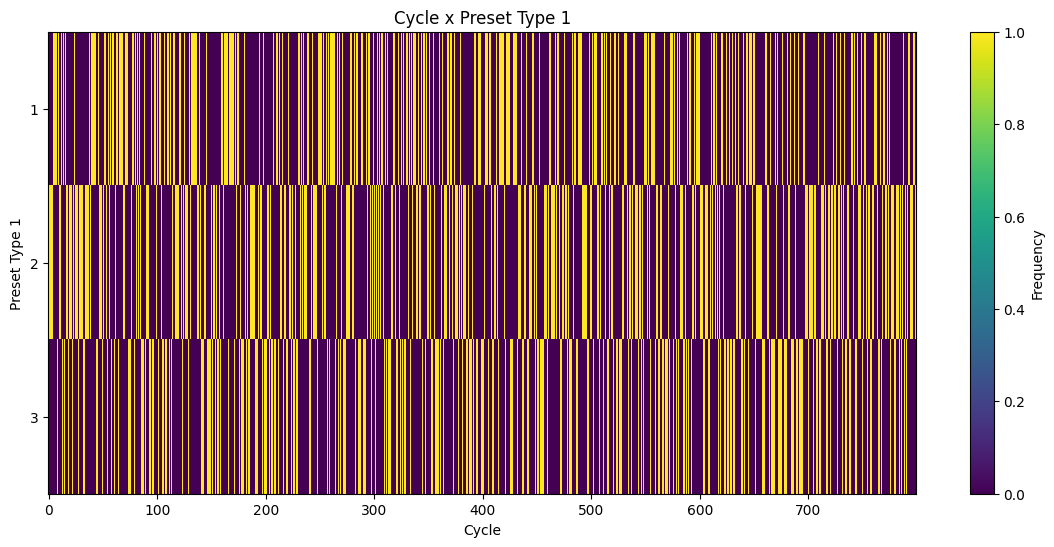

In [288]:
heat_data = pd.crosstab(
    d_raw["Preset_1"],
    d_raw["Cycle"]
)

plt.figure(figsize=(14,6))

plt.imshow(
    heat_data,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Frequency")

plt.xlabel("Cycle")
plt.ylabel("Preset Type 1")
plt.title("Cycle x Preset Type 1")

plt.yticks(
    range(len(heat_data.index)),
    heat_data.index
)

plt.show()

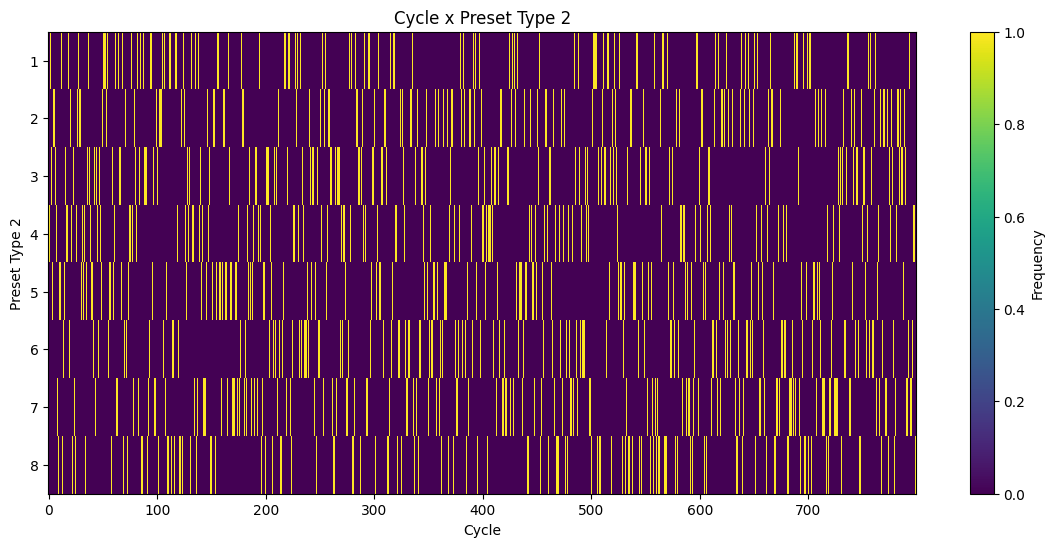

In [289]:
heat_data = pd.crosstab(
    d_raw["Preset_2"],
    d_raw["Cycle"]
)

plt.figure(figsize=(14,6))

plt.imshow(
    heat_data,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Frequency")

plt.xlabel("Cycle")
plt.ylabel("Preset Type 2")
plt.title("Cycle x Preset Type 2")

plt.yticks(
    range(len(heat_data.index)),
    heat_data.index
)

plt.show()

To investigate whether the operating regimes exhibit temporal dependence, the sequence of preset configurations was analyzed over time. Visual inspection does not reveal any clear temporal patterns, trends, or persistent regime structures. Instead, the preset configurations appear to alternate throughout the operating history without obvious clustering or long-term persistence.

While this initial assessment suggests that the operating regimes may not be strongly driven by time, visual inspection alone is insufficient to draw definitive conclusions. Therefore, a transition matrix analysis was performed to better understand the dynamics between operating regimes.

The transition matrix quantifies the probability of moving from one preset configuration to another between consecutive cycles. This analysis allows us to identify whether certain operating regimes tend to persist over time, whether specific transitions occur more frequently than expected, and whether failure events may be associated with particular regime changes.


In [290]:
d_raw["Preset_1_lag"] = (
    d_raw["Preset_1"].shift(1)
)

transition_matrix_Preset_1 = pd.crosstab(
    d_raw["Preset_1_lag"],
    d_raw["Preset_1"],
    normalize="index"
)

print(transition_matrix_Preset_1)

chisq_test_Preset_1 = scipy.stats.chi2_contingency(transition_matrix_Preset_1)
print(f"p-value: {chisq_test_Preset_1[1]}")

Preset_1             1         2         3
Preset_1_lag                              
1             0.329545  0.367424  0.303030
2             0.320285  0.359431  0.320285
3             0.342520  0.326772  0.330709
p-value: 0.9999973306249645


In [291]:
d_raw["Preset_2_lag"] = (
    d_raw["Preset_2"].shift(1)
)

transition_matrix_Preset_2 = pd.crosstab(
    d_raw["Preset_2_lag"],
    d_raw["Preset_2"],
    normalize="index"
)

print(transition_matrix_Preset_2)

chisq_test_Preset_2 = scipy.stats.chi2_contingency(transition_matrix_Preset_2)
print(f"p-value: {chisq_test_Preset_2[1]}")


Preset_2             1         2         3         4         5         6  \
Preset_2_lag                                                               
1             0.106383  0.138298  0.106383  0.095745  0.106383  0.138298   
2             0.158416  0.118812  0.158416  0.128713  0.118812  0.099010   
3             0.089109  0.079208  0.148515  0.178218  0.118812  0.128713   
4             0.172043  0.107527  0.107527  0.053763  0.139785  0.161290   
5             0.090000  0.140000  0.140000  0.110000  0.130000  0.100000   
6             0.128713  0.198020  0.118812  0.148515  0.118812  0.079208   
7             0.119266  0.137615  0.091743  0.100917  0.128440  0.146789   
8             0.090000  0.090000  0.140000  0.110000  0.140000  0.150000   

Preset_2             7         8  
Preset_2_lag                      
1             0.159574  0.148936  
2             0.089109  0.128713  
3             0.128713  0.128713  
4             0.150538  0.107527  
5             0.160000  0.130

The transition matrices for the operating regimes, together with the Pearson's Chi-Square test results, do not provide evidence of strong temporal dependence between consecutive operating states.

From a practical perspective, this suggests that the occurrence of a given preset configuration is not strongly determined by the immediately preceding operating state. Instead, the equipment appears to switch between operating regimes with relatively stable transition probabilities over time.

These findings indicate that temporal persistence is unlikely to be a primary driver of equipment behavior.

#### Multivariate Exploratory Data Analysis

Having established that the operating regimes do not exhibit strong temporal dependence, the next step is to investigate whether they are associated with different operating conditions.

To do so, we analyze the distributions of Temperature, Pressure, and Frequency across the different preset configurations. If significant differences are observed, this would support the hypothesis that each operating regime is characterized by its own expected range of sensor measurements.

In other words, a value that may be considered normal under one operating regime could represent abnormal behavior under another. Understanding these regime-specific operating conditions is therefore essential for both failure analysis and predictive modeling.

To formally assess these differences, the distributions of Temperature, Pressure, and Frequency are compared across preset configurations using both graphical analysis and non-parametric statistical tests. This approach allows us to determine whether the operating regimes correspond to distinct machine states with significantly different process characteristics.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

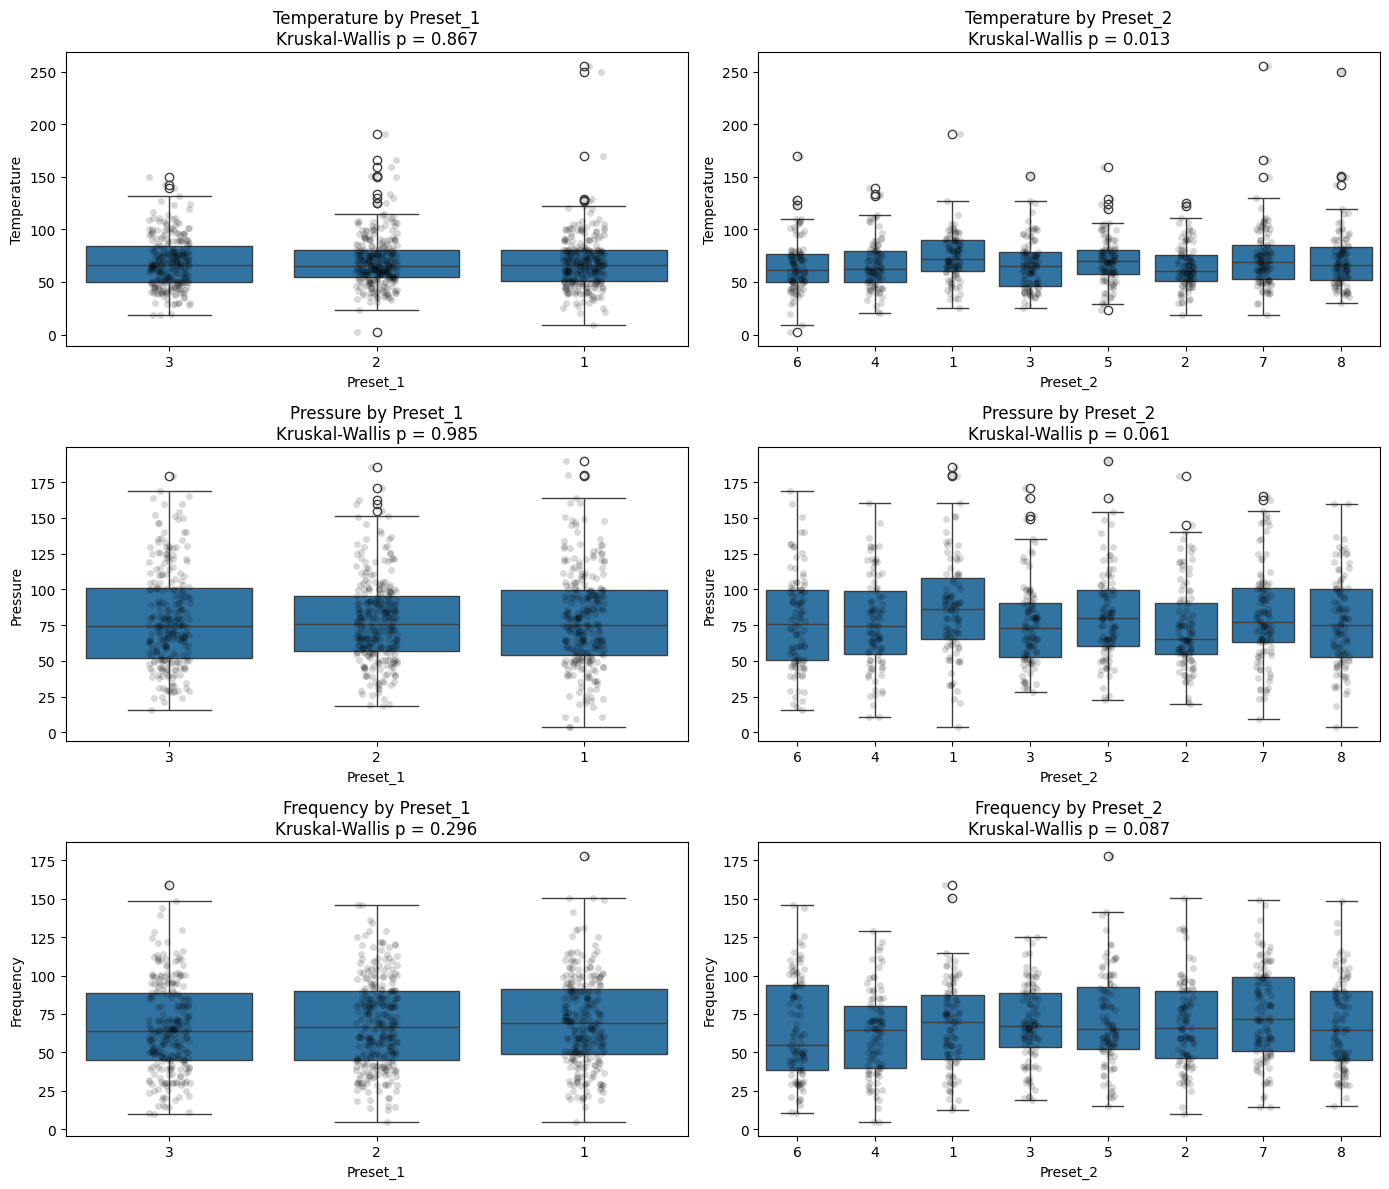

In [292]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

variables = ["Temperature", "Pressure", "Frequency"]
presets = ["Preset_1", "Preset_2"]

for i, var in enumerate(variables):
    for j, preset in enumerate(presets):

        ax = axes[i, j]

        sns.boxplot(
            data=d_raw,
            x=preset,
            y=var,
            ax=ax
        )
        
        sns.stripplot(
            data=d_raw,
            x=preset,
            y=var,
            ax=ax,
            alpha=0.15,
            size=5,
            color="black"
        )
        groups = [
            g[var].dropna().values
            for _, g in d_raw.groupby(preset)
        ]

        stat, pvalue = scipy.stats.kruskal(*groups)

        p_label = "<0.001" if pvalue < 0.001 else f"{pvalue:.3f}"

        axes[i, j].set_title(
            f"{var.capitalize()} by {preset}\nKruskal-Wallis p = {p_label}"
        )

plt.tight_layout()
plt.show()

Combining the visual inspection of the boxplots with the Kruskal-Wallis test results, we find little evidence that the distributions of Temperature, Pressure, and Frequency differ across the levels of Preset_1. This suggests that Preset_1 is not strongly associated with distinct operating conditions for these variables.

In contrast, more pronounced differences are observed across the levels of Preset_2. For Temperature, the distribution is noticeably shifted upward when Preset_2 equals 1, and the Kruskal-Wallis test provides strong statistical evidence supporting this difference.

A similar pattern is observed for Pressure, with higher values associated with Preset_2 = 1. Although the corresponding p-value is slightly above the conventional 5% significance threshold (p = 0.06), it still provides suggestive evidence that Pressure may vary across operating regimes.

For Frequency, neither the visual analysis nor the statistical test indicates meaningful differences between the Preset_2 configurations at the 5% significance level.

Overall, these results suggest that Preset_2 captures relevant differences in the equipment's operating conditions, particularly regarding Temperature and, to a lesser extent, Pressure. Consequently, Preset_2 may provide valuable contextual information when modeling equipment failures and interpreting other measurements.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

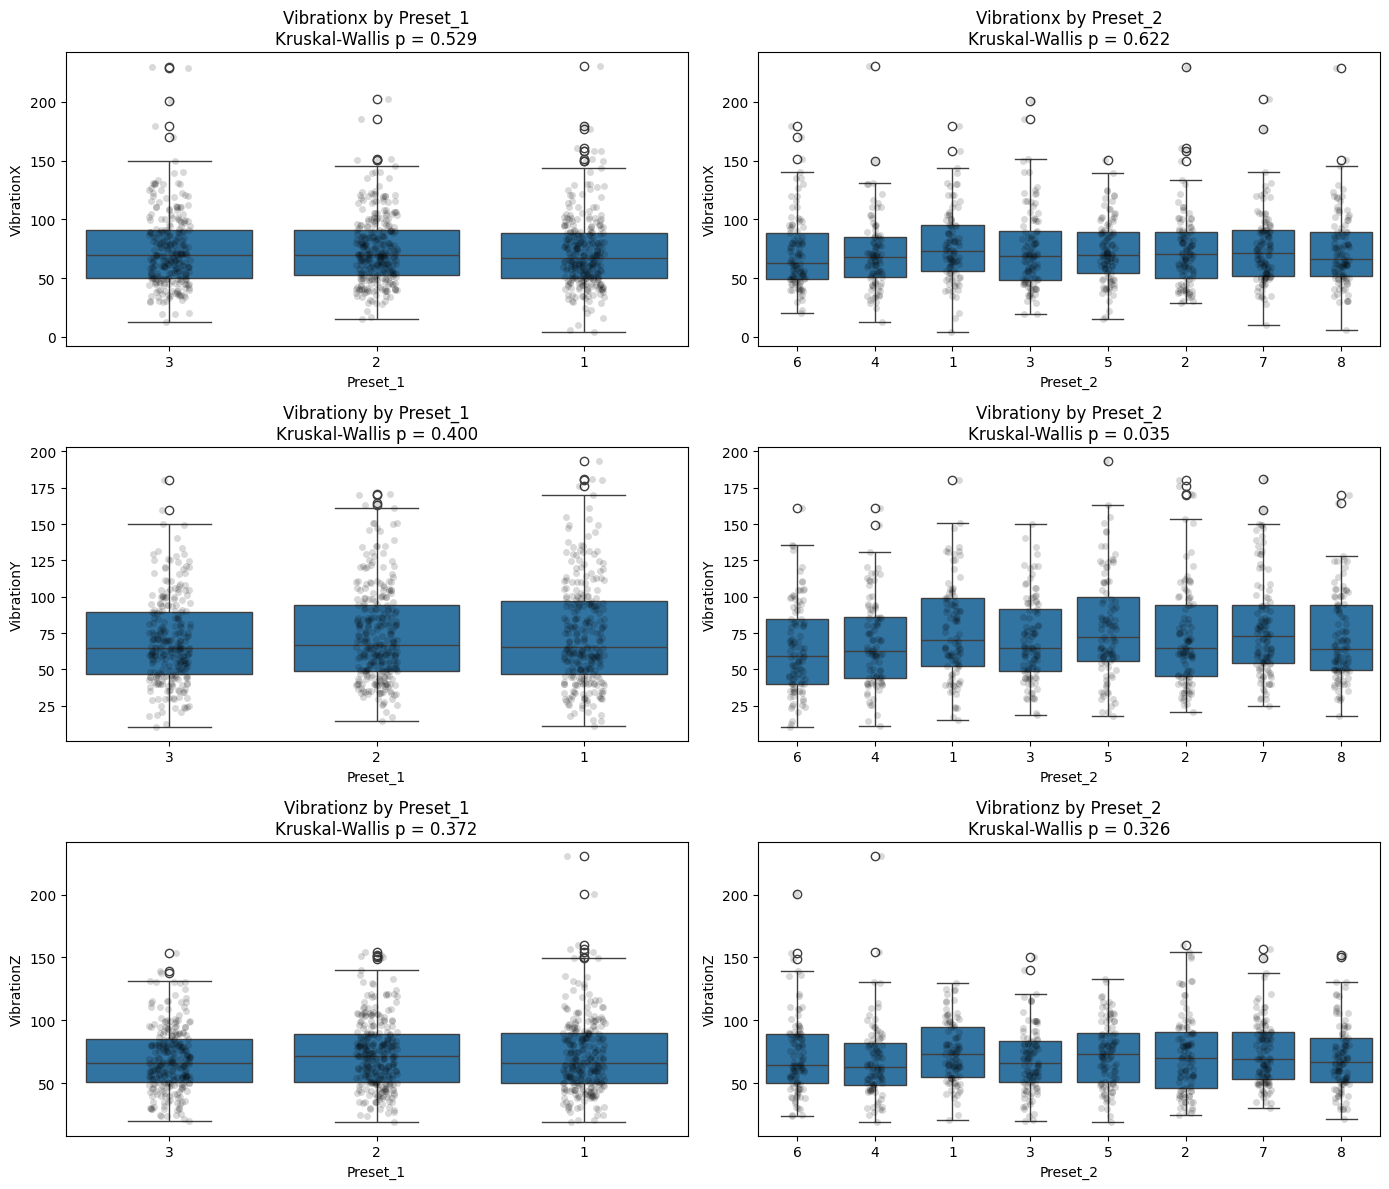

In [293]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

variables = ["VibrationX", "VibrationY", "VibrationZ"]
presets = ["Preset_1", "Preset_2"]

for i, var in enumerate(variables):
    for j, preset in enumerate(presets):

        ax = axes[i, j]

        sns.boxplot(
            data=d_raw,
            x=preset,
            y=var,
            ax=ax
        )
        
        sns.stripplot(
            data=d_raw,
            x=preset,
            y=var,
            ax=ax,
            alpha=0.15,
            size=5,
            color="black"
        )
        groups = [
            g[var].dropna().values
            for _, g in d_raw.groupby(preset)
        ]

        stat, pvalue = scipy.stats.kruskal(*groups)

        p_label = "<0.001" if pvalue < 0.001 else f"{pvalue:.3f}"

        axes[i, j].set_title(
            f"{var.capitalize()} by {preset}\nKruskal-Wallis p = {p_label}"
        )

plt.tight_layout()
plt.show()

The analysis of the vibration measurements along the X, Y, and Z axes suggests that only the Y-axis vibration is meaningfully associated with the operating regimes.

For VibrationX and VibrationZ, the boxplots and Kruskal-Wallis tests do not provide evidence of significant distributional differences across the preset configurations, indicating that these measurements remain relatively stable across operating conditions.

In contrast, VibrationY exhibits statistically significant differences across the levels of Preset_2. Both the visual analysis and the Kruskal-Wallis test suggest that the operating regime influences the vibration behavior along the Y-axis.

More specifically, higher vibration levels are observed for Preset_2 values of 1, 5, and 7, indicating that these operating regimes may impose greater mechanical stress or different dynamic conditions on the equipment. This finding reinforces the interpretation that Preset_2 captures relevant operational characteristics and should be considered when analyzing equipment behavior and developing failure prediction models.

Taken together, the previous findings indicate that Preset_2 is associated with meaningful changes in Temperature, Pressure, and VibrationY, while Preset_1 appears to have a more limited relationship with the monitored process variables.


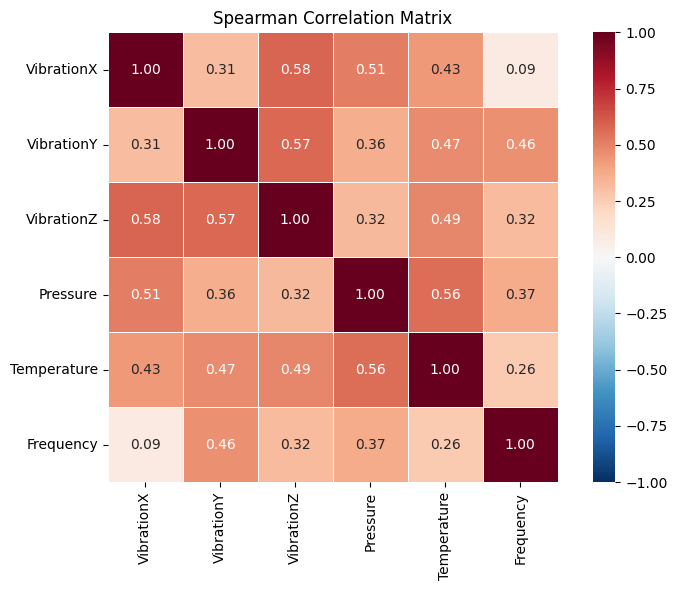

In [294]:
corr_vars = [
    "VibrationX",
    "VibrationY",
    "VibrationZ",
    "Pressure",
    "Temperature",
    "Frequency"
]

corr_matrix = (
    d_raw[corr_vars]
    .corr(method="spearman")
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

The Spearman correlation matrix was used to evaluate the monotonic relationships among the process variables. Overall, the results indicate relatively weak to moderate associations between the sensor measurements, suggesting a limited degree of redundancy among the available features.

The strongest relationships are observed between VibrationZ and the other vibration measurements, VibrationX and VibrationY, both presenting correlation coefficients of approximately 0.51. Although these associations are noticeable, they remain below levels that would typically raise concerns regarding multicollinearity.

For the remaining variables, the observed correlations are generally weak, indicating that each sensor may provide complementary information about the equipment's operating condition.

While correlation analysis is useful for identifying monotonic relationships, it may fail to capture more complex patterns and interactions between variables. Therefore, scatter plots are also examined to investigate potential non-linear relationships or clusters that may not be evident from the correlation matrix alone.

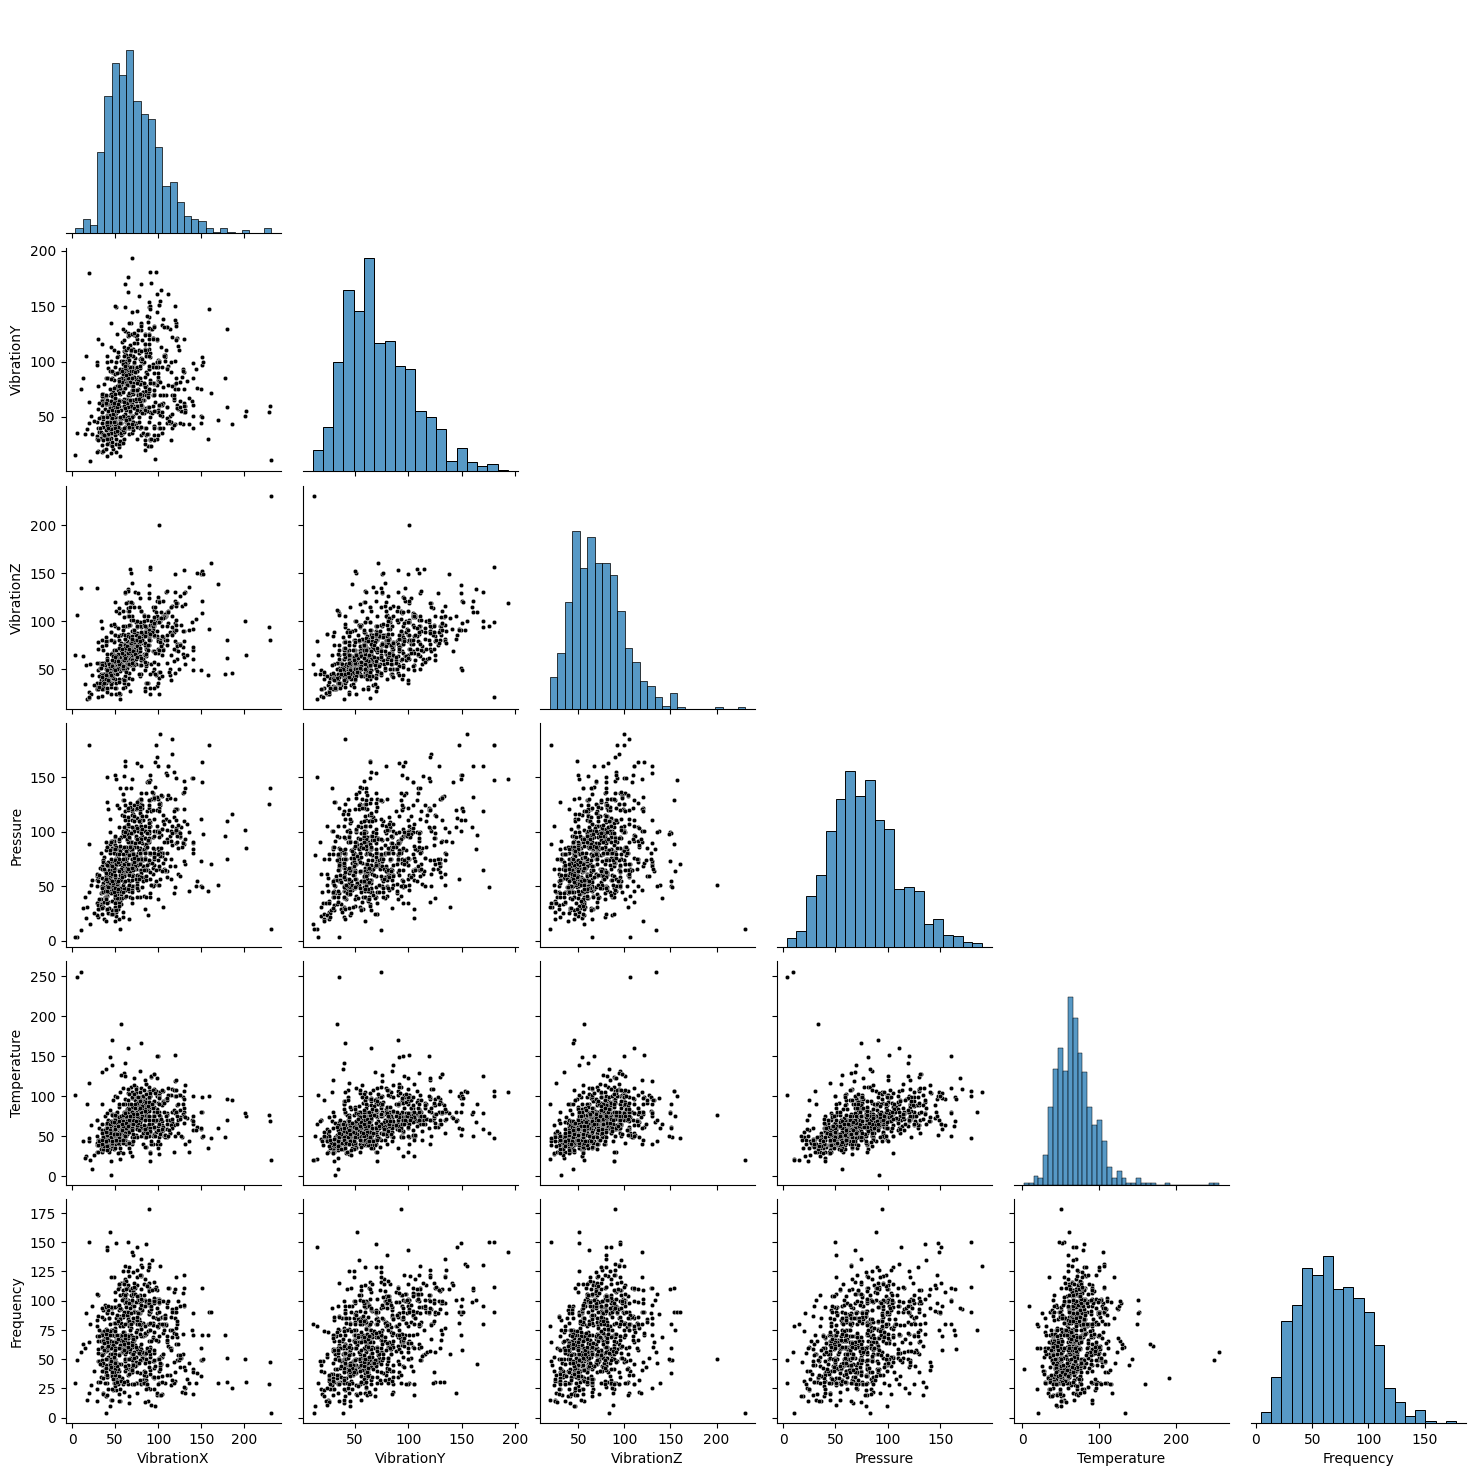

In [295]:
sns.pairplot(
    d_raw[corr_vars],
    kind="scatter",
    corner=True,
    plot_kws={
        "s": 10,
        "color": "black"
    }
)

plt.show()

The scatter plots provide additional insight into the relationships between the process variables. Consistent with the Spearman correlation analysis, the vibration measurements exhibit positive associations, particularly between VibrationX and VibrationZ. However, these relationships are far from deterministic and display considerable dispersion.

A notable characteristic observed across several variable pairs is the presence of heteroscedasticity. In general, as the values of the variables increase, the spread of the observations also tends to increase. This behavior suggests that the variability of the equipment's operating conditions is not constant throughout its operating range, with higher operating levels being associated with greater uncertainty and variability.

This pattern is not restricted to the vibration measurements and can also be observed in other process variables. As a result, simple linear relationships may not fully capture the underlying dynamics of the equipment.

To further investigate these relationships, particular attention is given to the VibrationX versus VibrationZ and Temperature versus Pressure scatter plots. These variable pairs exhibit the strongest associations observed in the dataset and may reveal operating patterns that are not immediately evident from summary statistics alone.

In addition, the analysis is extended by incorporating Preset_2, the operating regime variable that previously showed statistically significant associations with several process measurements. By stratifying the scatter plots according to Preset_2, we can assess whether the observed relationships remain consistent across operating regimes or whether distinct operating states exhibit different patterns of behavior.


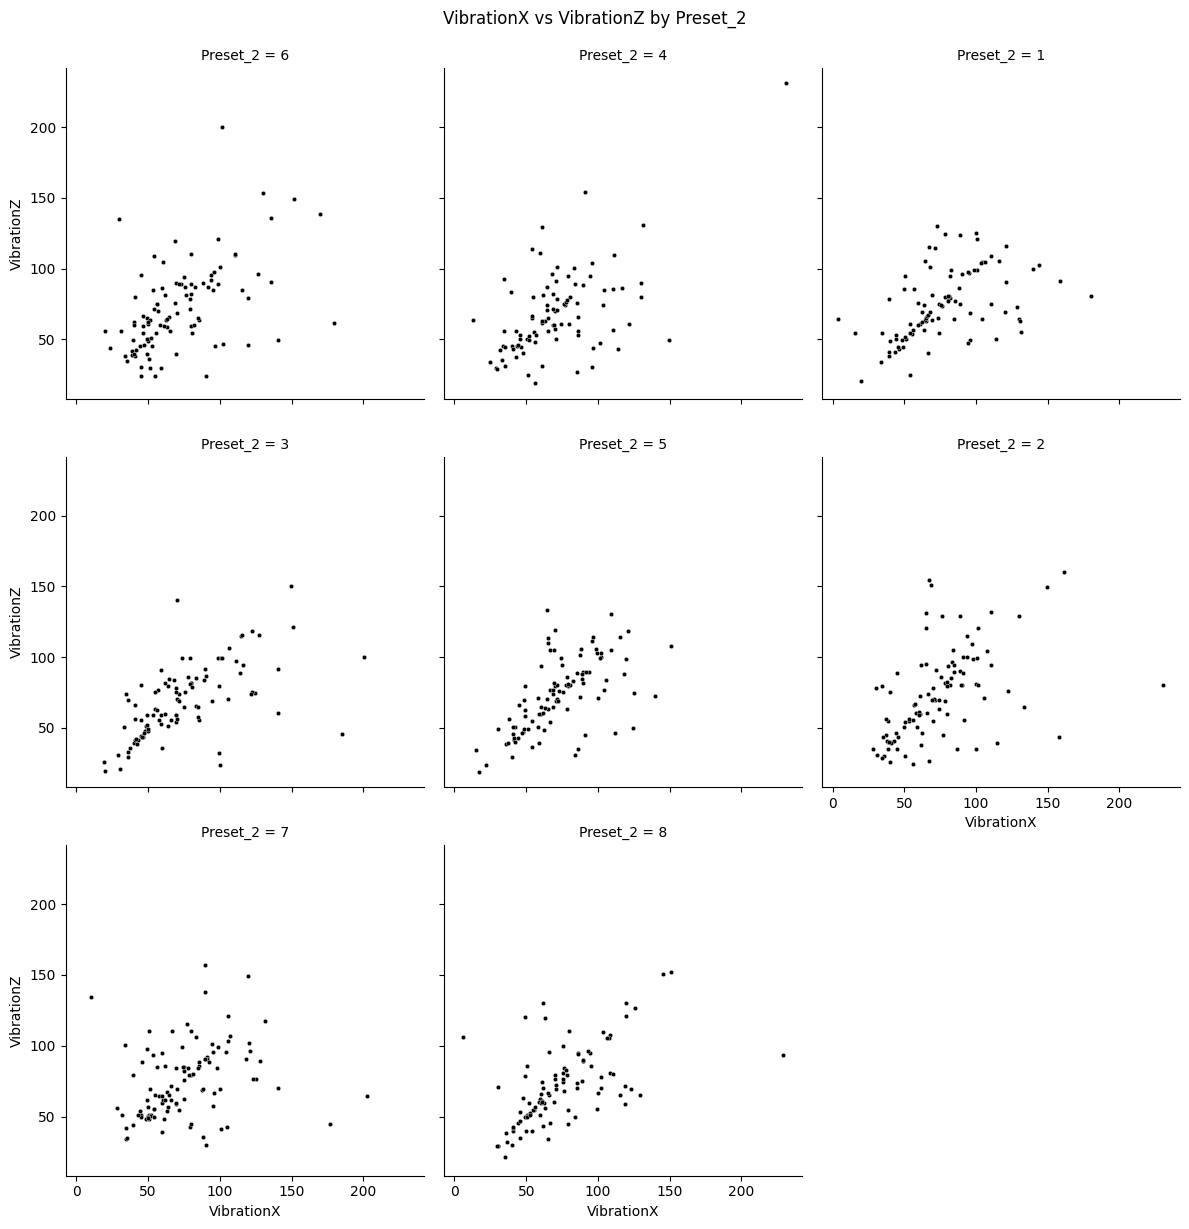

In [296]:
g = sns.FacetGrid(
    d_raw,
    col="Preset_2",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x="VibrationX",
    y="VibrationZ",
    color="black",
    s=10
)

g.fig.suptitle(
    "VibrationX vs VibrationZ by Preset_2",
    y=1.02
)

plt.show()

When examining the relationship between VibrationX and VibrationZ across the different operating regimes, the overall positive association remains consistent with the patterns previously observed in the correlation analysis.

Some operating regimes, particularly those associated with Preset_2 values of 3, 5, and 8, appear to exhibit a slightly stronger relationship between the two vibration measurements. In these regimes, the observations tend to align more closely along a common trend, suggesting a greater degree of coupling between the vibration responses measured on the X and Z axes.

However, the observed differences are relatively subtle, and no clearly distinct clusters or regime-specific patterns emerge from the data. 

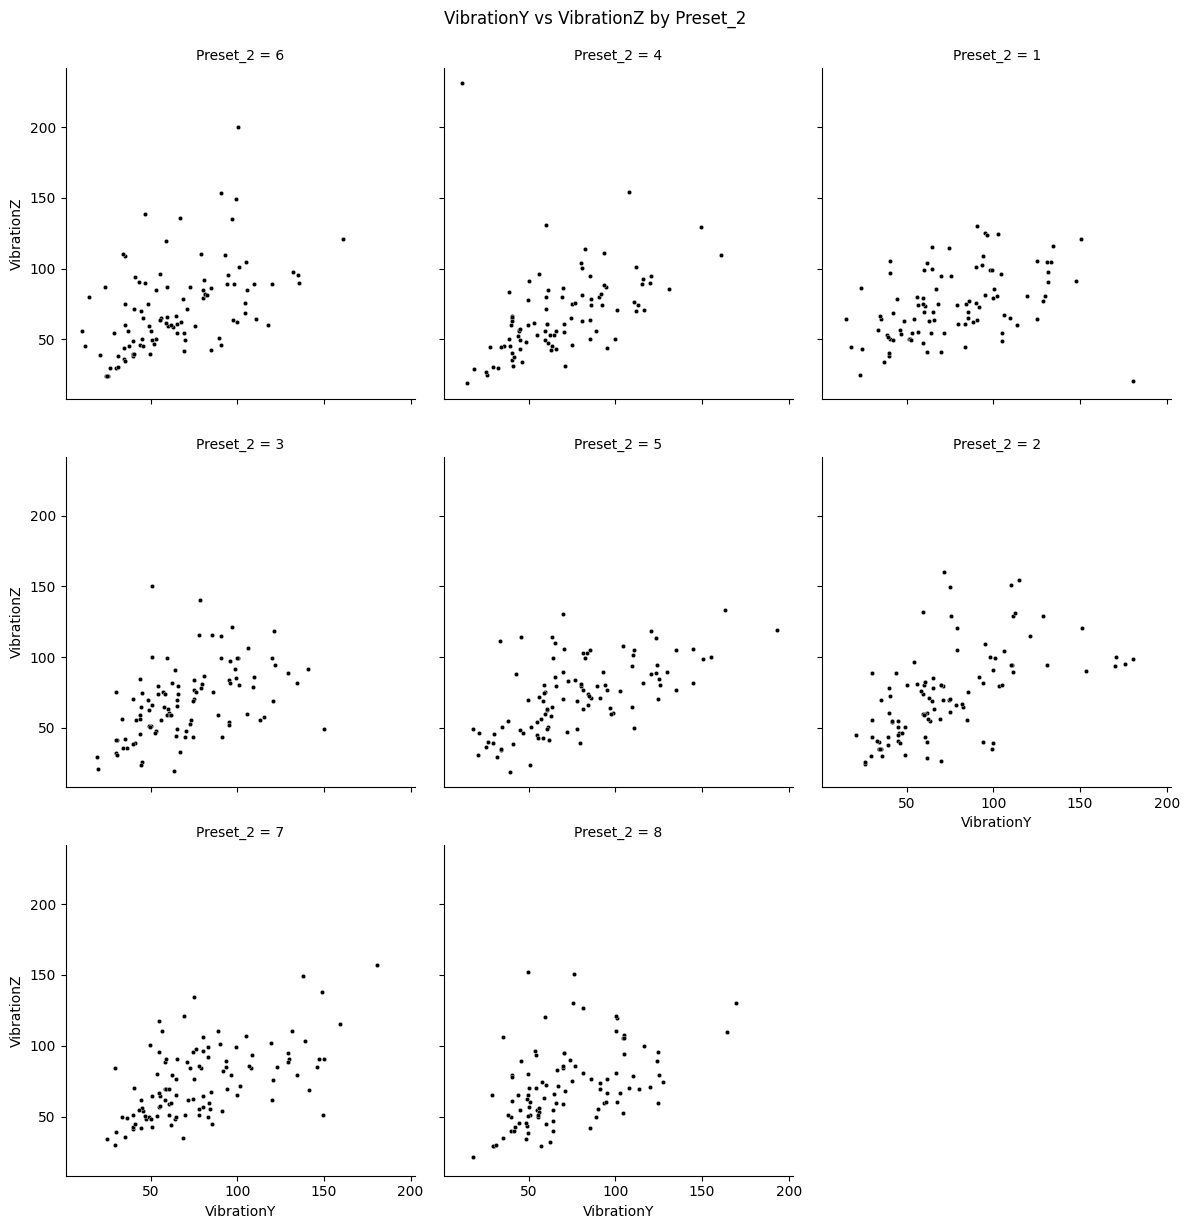

In [297]:
g = sns.FacetGrid(
    d_raw,
    col="Preset_2",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x="VibrationY",
    y="VibrationZ",
    color="black",
    s=10
)

g.fig.suptitle(
    "VibrationY vs VibrationZ by Preset_2",
    y=1.02
)

plt.show()

A similar pattern is observed for the relationship between VibrationY and VibrationZ. The association remains positive across the different operating regimes, and the overall structure of the scatter plots closely resembles that observed for VibrationX and VibrationZ. Consequently, no meaningful differences were observed in the correlations among the vibration measurements across the different operating regimes.


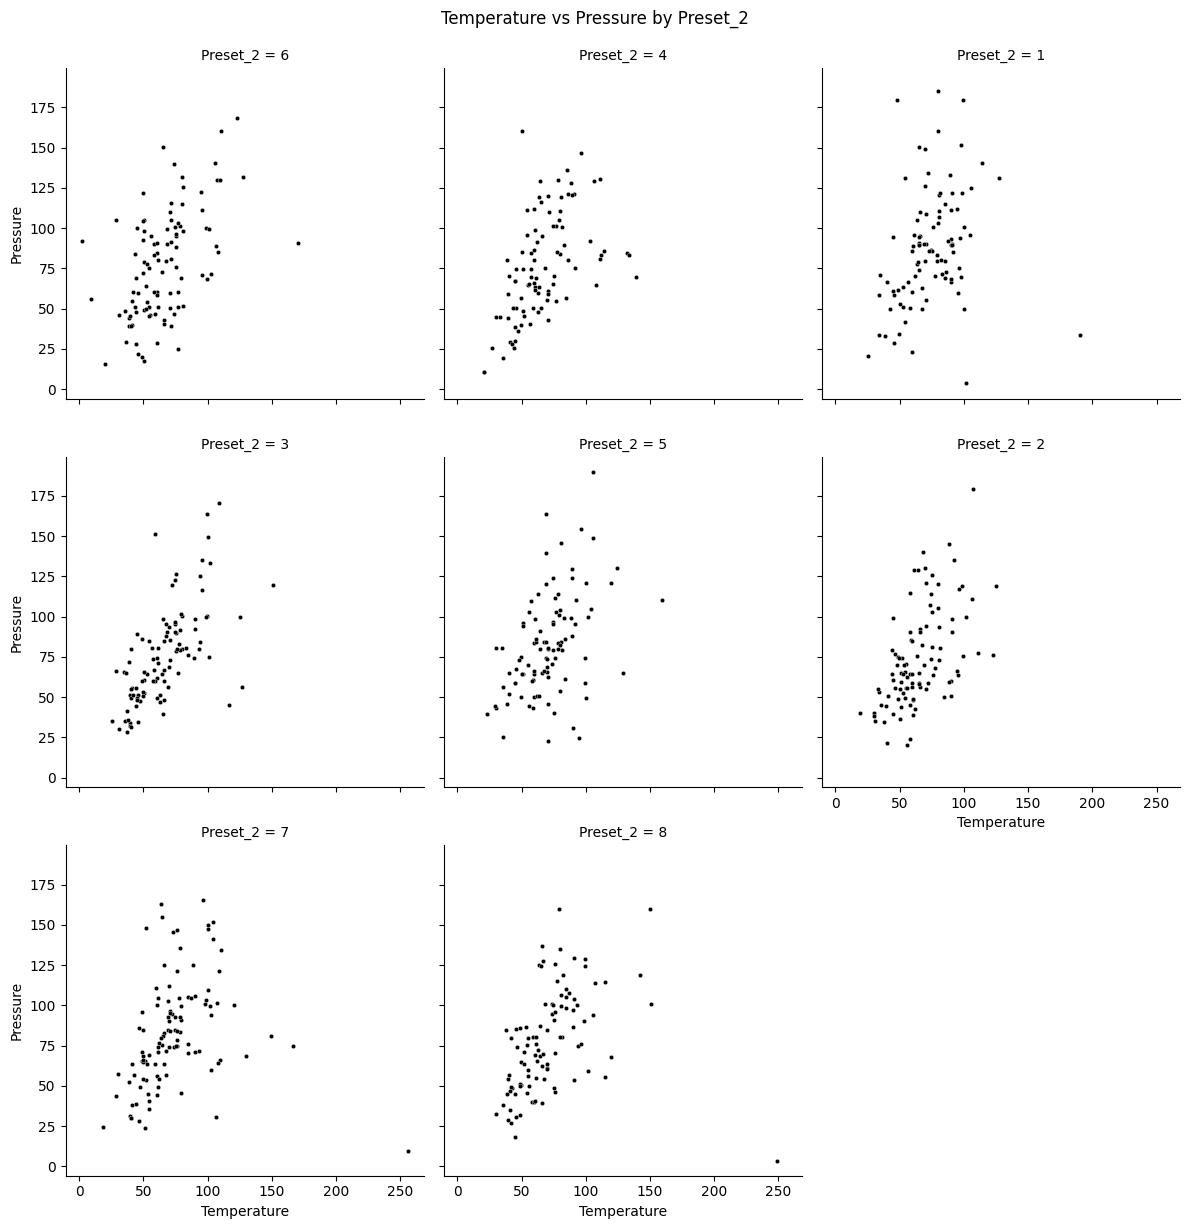

In [298]:
g = sns.FacetGrid(
    d_raw,
    col="Preset_2",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x="Temperature",
    y="Pressure",
    color="Black",
    s=10
)

g.fig.suptitle(
    "Temperature vs Pressure by Preset_2",
    y=1.02
)

plt.show()

A similar pattern is observed in the relationship between Temperature and Pressure. Higher levels of correlation between these variables can be identified for operating regimes associated with Preset_2 values of 4, 1, 3, and 2.

These findings suggest that the relationship between Temperature and Pressure is influenced by the machine's operating regime. Depending on the operational state, stronger associations can be observed between these two process variables. As both Temperature and Pressure are key indicators of equipment operating conditions, they may also be closely related to the occurrence of failure events.


### Bivariate Analysis

Having explored the relationships among the explanatory variables and gained a better understanding of the equipment's operating conditions, the next step is to investigate how the observed failure events relate to the process variables.

To accomplish this, a bivariate analysis is performed between each explanatory variable and the target variable representing equipment failures. The primary objective is to identify which variables exhibit the strongest discriminatory power between failure and non-failure observations, as well as to understand the patterns through which these failures emerge.

For the numerical variables, the Empirical Cumulative Distribution Function (ECDF) is evaluated separately for failure and non-failure observations. Comparing these distributions provides a visual assessment of how effectively each variable distinguishes between the two classes and highlights the regions where failures are more likely to occur.

In addition, the Kolmogorov-Smirnov (KS) statistic is computed for each variable. The KS statistic measures the maximum distance between the ECDFs of the failure and non-failure groups and therefore provides a quantitative measure of the variable's discriminatory power. Variables with larger KS values are expected to be more informative for predicting equipment failures and may play an important role in the subsequent modeling stage.


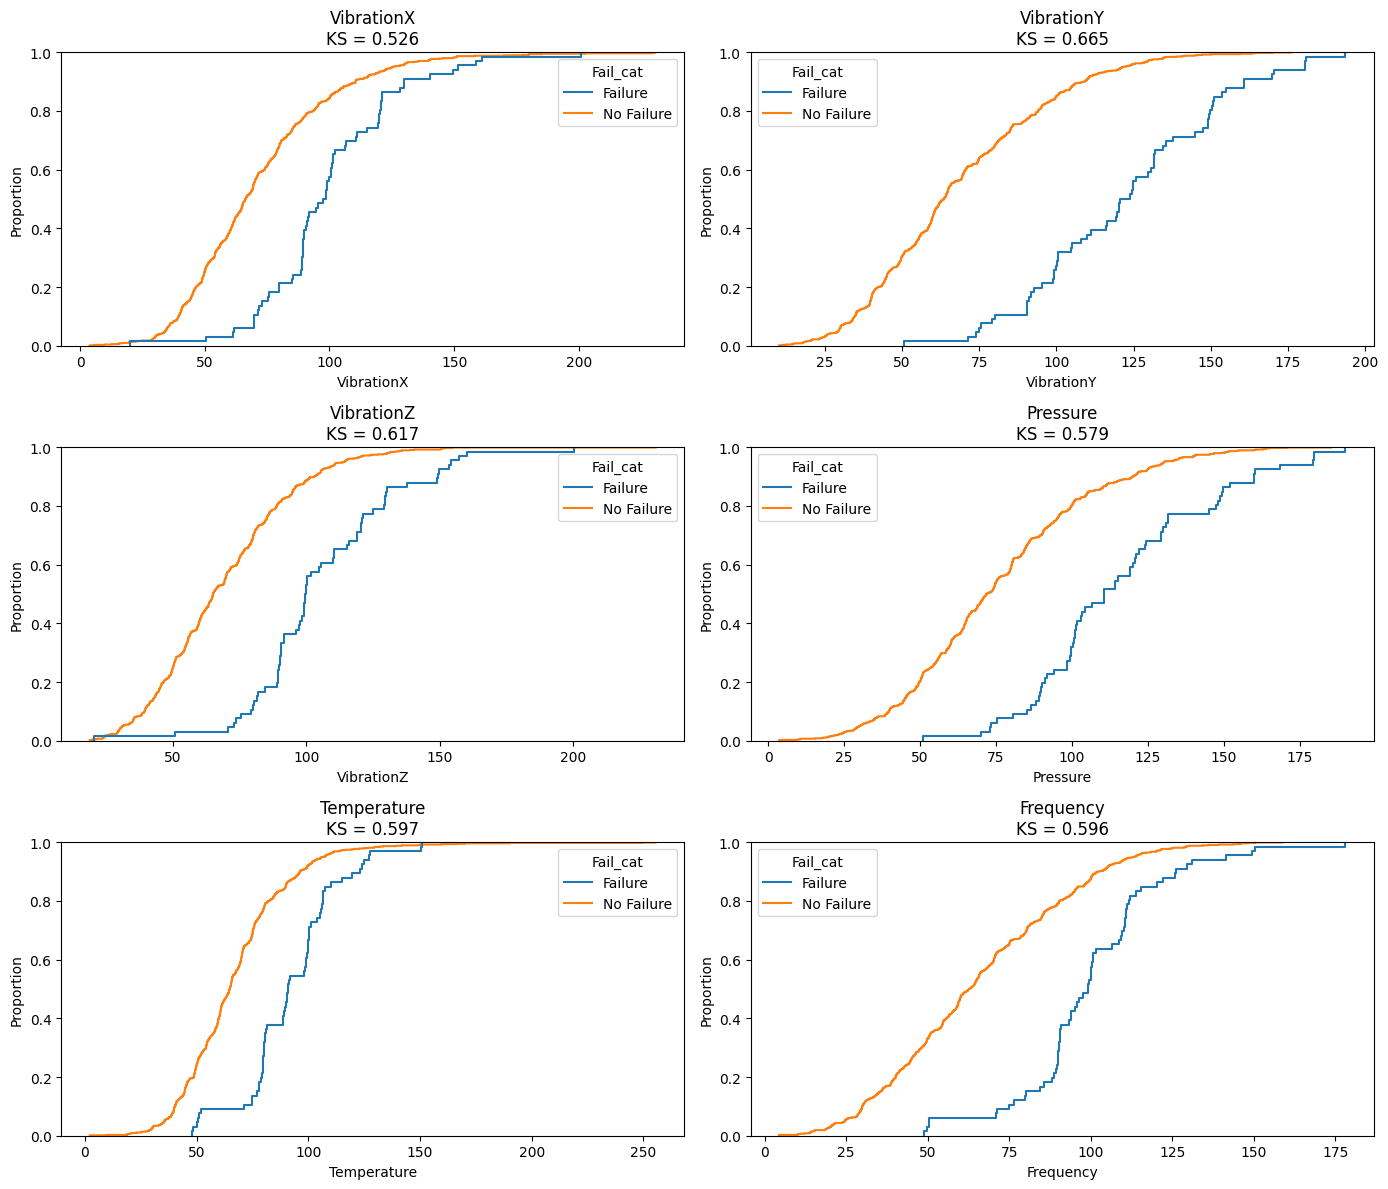

In [299]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

vars = [
    "VibrationX",
    "VibrationY",
    "VibrationZ",
    "Pressure",
    "Temperature",
    "Frequency"
]

for ax, var in zip(axes, vars):

    sns.ecdfplot(
        data=d_raw,
        x=var,
        hue="Fail_cat",
        ax=ax
    )

    normal = d_raw.loc[d_raw["Fail_cat"] == "No Failure", var]
    failure = d_raw.loc[d_raw["Fail_cat"] == "Failure", var]

    stat, pvalue = scipy.stats.ks_2samp(
        normal,
        failure
    )

    ax.set_title(
        f"{var}\nKS = {stat:.3f}"
    )

plt.tight_layout()
plt.show()

By jointly analyzing the ECDFs and the corresponding KS statistics, all numerical variables appear to exhibit meaningful discriminatory power between failure and non-failure observations. Using a reference KS value of 0.20, which is commonly considered indicative of good predictive performance, all evaluated variables exceed this threshold and therefore show potential usefulness for failure prediction.

Among the analyzed variables, VibrationY demonstrates the strongest discriminatory capability, followed by VibrationZ. This finding is consistent with previous analyses, where vibration measurements showed meaningful relationships with operating conditions and may therefore contain valuable information regarding equipment degradation.

An interesting result is observed for Frequency. Although its overall KS statistic ranks among the highest in the dataset, the separation between failure and non-failure observations is concentrated within a specific range of values. The largest differences between the ECDFs occur approximately between Frequency values of 100 and 110, after which the discriminatory power gradually decreases.

This behavior suggests that the predictive contribution of Frequency is not uniform across its entire operating range. Instead, the variable appears to be particularly informative within specific intervals, indicating the possible existence of operating thresholds or critical frequency ranges associated with increased failure risk.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


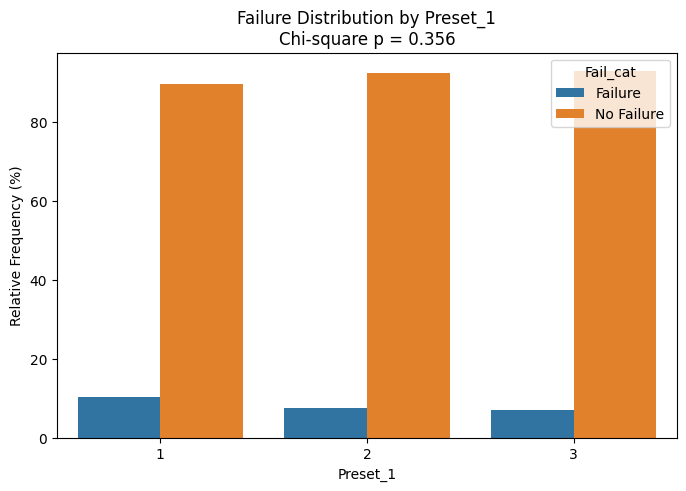

In [300]:
tab = pd.crosstab(
    d_raw["Preset_1"],
    d_raw["Fail_cat"]
)

chi2, pvalue, dof, expected = scipy.stats.chi2_contingency(tab)

plot_data = (
    pd.crosstab(
        d_raw["Preset_1"],
        d_raw["Fail_cat"],
        normalize="index"
    )
    .mul(100)
    .reset_index()
    .melt(
        id_vars="Preset_1",
        var_name="Fail_cat",
        value_name="Percentage"
    )
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=plot_data,
    x="Preset_1",
    y="Percentage",
    hue="Fail_cat"
)

p_label = "<0.001" if pvalue < 0.001 else f"{pvalue:.3f}"

plt.title(
    f"Failure Distribution by Preset_1\nChi-square p = {p_label}"
)

plt.ylabel("Relative Frequency (%)")
plt.xlabel("Preset_1")

plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


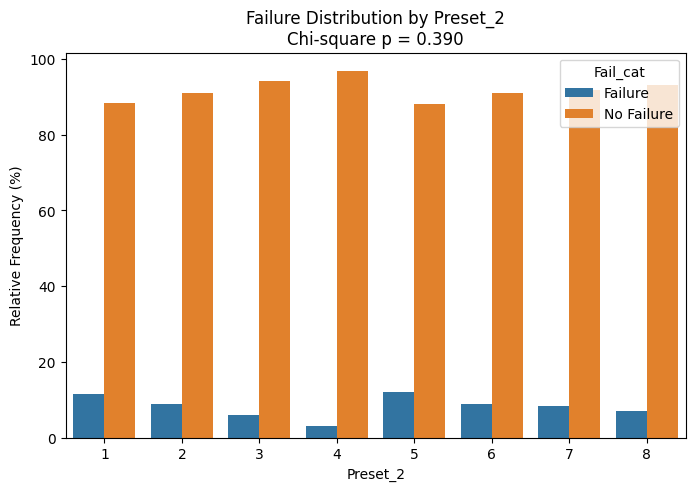

In [301]:
tab = pd.crosstab(
    d_raw["Preset_2"],
    d_raw["Fail_cat"]
)

chi2, pvalue, dof, expected = scipy.stats.chi2_contingency(tab)

plot_data = (
    pd.crosstab(
        d_raw["Preset_2"],
        d_raw["Fail_cat"],
        normalize="index"
    )
    .mul(100)
    .reset_index()
    .melt(
        id_vars="Preset_2",
        var_name="Fail_cat",
        value_name="Percentage"
    )
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=plot_data,
    x="Preset_2",
    y="Percentage",
    hue="Fail_cat"
)

p_label = "<0.001" if pvalue < 0.001 else f"{pvalue:.3f}"

plt.title(
    f"Failure Distribution by Preset_2\nChi-square p = {p_label}"
)

plt.ylabel("Relative Frequency (%)")
plt.xlabel("Preset_2")

plt.show()

The relationship between the operating regime variables (Preset_1 and Preset_2) and equipment failures was evaluated using Pearson's Chi-Square test. The results do not provide statistical evidence of an association between these variables and the occurrence of failures at the conventional significance levels.

For Preset_1, both the visual inspection and the statistical test suggest little evidence of a meaningful relationship with failure events. For Preset_2, however, some differences can be observed between the failure rates across operating regimes. Although these differences appear notable from a descriptive perspective, the corresponding statistical test was not significant.

Given the relatively small number of failure events in the dataset (66 observations), the statistical power of the test may be limited. As a result, while the observed patterns suggest that Preset_2 could be related to failure occurrence, the available evidence is insufficient to support a reliable conclusion.

Therefore, Preset_2 should not be interpreted as a direct failure indicator based solely on this analysis. Nevertheless, because previous analyses demonstrated that Preset_2 is associated with meaningful changes in operating conditions and sensor behavior, it may still contribute indirectly to failure prediction when combined with other process variables in a multivariate modeling framework.

Furthermore, considering the limited number of failure events and the relatively high cardinality of Preset_2, the expected predictive gain from including this variable is likely to be marginal. For this reason, Preset_2 will be excluded from the final modeling stage in favor of a more parsimonious model specification.



### Modelling

Having completed the exploratory and bivariate analyses, the next step is to develop predictive models capable of identifying potential equipment failures before they occur.

To evaluate model performance, the dataset was divided into training and testing samples. Since the observations are sequentially organized by operating cycles, a traditional random train-test split would introduce information leakage and result in overly optimistic performance estimates. Therefore, a time-aware validation strategy was adopted.

Specifically, an expanding window validation approach was used, as illustrated in the figure below.

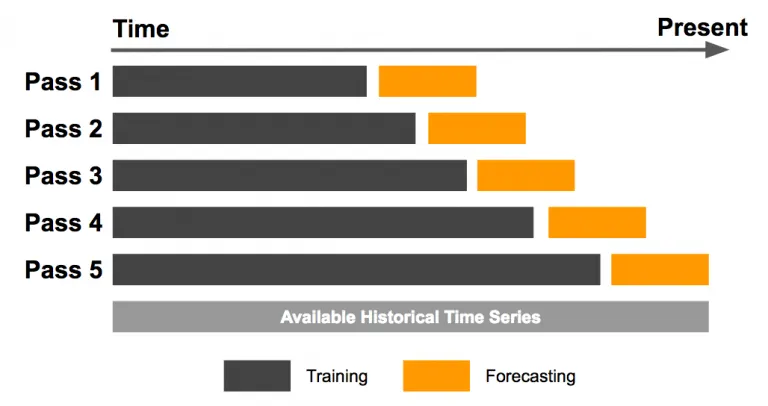


The ten most recent cycles were reserved for out-of-sample evaluation. However, rather than training a single model and testing it on all ten cycles simultaneously, the model was re-estimated sequentially following the natural evolution of time.

For example:

To predict Cycle 701, the model is trained using all observations up to Cycle 700.
To predict Cycle 702, the model is trained using all observations up to Cycle 701.
This process continues until the final test cycle is reached.

As a result, each test observation is evaluated using only information that would have been available at the time the prediction was made, closely replicating a real-world deployment scenario.

For each expanding window iteration, the model is trained, a prediction is generated for the corresponding test cycle, and the prediction outcome is recorded. After all test cycles have been evaluated, model performance is assessed using the F1-score.

The F1-score was selected as the primary evaluation metric because the dataset is moderately imbalanced, with failure events representing only 8.25% of the observations. This metric balances Precision and Recall, providing a more informative assessment than overall accuracy.

From a practical perspective, optimizing the F1-score helps reduce both:

False Negatives: failure events incorrectly classified as normal operation. These are particularly critical because they may lead to unexpected equipment failures.
False Positives: normal operating conditions incorrectly classified as failures, potentially resulting in unnecessary maintenance actions.

#### Candidate Models

Based on the exploratory analysis, the relationships between the process variables appear to vary across operating conditions. In particular, different operating regimes were associated with changes in both variable distributions and correlation structures. Consequently, flexible non-linear models are expected to be well-suited for this problem.

Three tree-based machine learning algorithms were selected as candidate models:

- Decision Tree
- Random Forest
- XGBoost

These methods are capable of capturing non-linear relationships, variable interactions, and regime-dependent decision boundaries without requiring strong distributional assumptions.

For each candidate model, a hyperparameter tuning procedure was performed using the out-of-sample aprouch showed before to identify the best-performing configuration among a predefined set of candidate values.

In addition to the tree-based models, a Linear Discriminant Analysis (LDA) model was also evaluated as a baseline classifier.

LDA remains a widely used statistical classification technique due to its simplicity, interpretability, and robustness when working with relatively small datasets.

LDA assumes that the explanatory variables follow class-specific multivariate normal distributions with a common covariance structure and seeks to find the linear combination of features that best separates failure and non-failure observations. Despite these assumptions, LDA often provides competitive performance in industrial applications and serves as an important benchmark against more complex machine learning algorithms.

Including LDA in the comparison allows us to assess whether the additional complexity introduced by ensemble and boosting methods translates into meaningful predictive gains. If a simple linear classifier achieves performance comparable to that of more sophisticated models, it may be preferred due to its interpretability, computational efficiency, and ease of deployment.

In [302]:
# Preparing data
target = "Fail_bin"

features = [
    "Temperature",
    "Pressure",
    "VibrationX",
    "VibrationY",
    "VibrationZ",
    "Frequency"
]

d_model = d_raw.sort_values("Cycle").copy()

X = d_model[features]
y = d_model[target]

#X = pd.get_dummies(
#    X,
#    columns=["Preset_2"],
#    drop_first=True,
#    dtype
#    =int
#)

# Defining train/test split

X_train = X.iloc[:len(X)-20]
y_train = y.iloc[:len(X)-20]

X_test = X.iloc[len(X)-20:len(X)]
y_test = y.iloc[len(X)-20:len(X)]

In [303]:
logging.basicConfig(
    level=logging.INFO,
    force=True
)

def expanding_window_tuning(
    X_train,
    y_train,
    X_test,
    y_test,
    model,
    param_grid,
    test_size=10,
    scoring="f1"
):
    predictions = []
    probabilities = []
    true_values = []
    best_params_list = []

    #start_test = len(X) - test_size
    
    n_cores = os.cpu_count()
    n_jobs = max(1, math.floor(n_cores * 0.6))

    logging.info(f"Available cores: {n_cores}")
    logging.info(f"Cores used in GridSearchCV: {n_jobs}")
        
    windows_test = sklearn.model_selection.TimeSeriesSplit(n_splits=test_size)

    grid = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        scoring = scoring,
        cv = windows_test,
        n_jobs = n_jobs
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    if hasattr(best_model, "predict_proba"):
        y_prob_train = best_model.predict_proba(X_train)[:, 1]
        y_prob_test = best_model.predict_proba(X_test)[:, 1]
    else:
        y_prob_train = np.repeat(np.nan, len(X_train))
        y_prob_test = np.repeat(np.nan, len(X_test))

    best_params_list.append(grid.best_params_)

    results_train = pd.DataFrame({
        "y_true": y_train.to_numpy(),
        "y_prob": y_prob_train,
    }, index = y_train.index)

    results_test = pd.DataFrame({
        "y_true": y_test.to_numpy(),
        "y_prob": y_prob_test,
    }, index = y_test.index)

    return {"train": results_train, "test": results_test, "best_params": best_params_list, "best_model": best_model}
       
     

#### Hyperparameter Tuning

For each candidate model, a hyperparameter tuning procedure was performed to identify the configuration that provided the best predictive performance under the expanding window validation framework.

The evaluated hyperparameters and their respective roles are summarized below.

**Decision Tree**

The Decision Tree model was tuned using the following hyperparameters:

max_depth: [2, 3, 4]
min_samples_leaf: [5, 10, 20]
criterion: ["gini", "entropy"]

- max_depth controls the maximum depth of the tree. Larger values allow the model to capture more complex relationships but may increase the risk of overfitting.
- min_samples_leaf defines the minimum number of observations required in each terminal node. Higher values produce smoother and more generalizable decision boundaries.
- criterion determines how the quality of each split is evaluated. The Gini index and Entropy are two commonly used impurity measures for classification trees.

**Random Forest**

The Random Forest model was tuned using:

n_estimators: [20, 40, 50]
max_depth: [2, 3, 4]
min_samples_leaf: [5, 10, 20]
max_features: ["sqrt", "log2"]
criterion: ["gini", "entropy"]
bootstrap: [True, False]

- n_estimators controls the number of trees in the ensemble. More trees generally improve stability and predictive performance but increase computational cost.
- max_depth limits the complexity of individual trees.
- min_samples_leaf regulates the minimum number of observations in each terminal node, helping prevent overfitting.
- max_features specifies the number of predictors randomly considered at each split. This introduces diversity among trees and improves ensemble performance.
- criterion defines the impurity measure used to evaluate splits.
- bootstrap determines whether trees are trained using bootstrap samples (sampling with replacement) or the entire training dataset.

**XGBoost**

The XGBoost model was tuned using:

n_estimators: [20, 40, 50]
max_depth: [2, 3, 4]
learning_rate: [0.01, ..., 0.10]
subsample: [0.8, 1.0]
colsample_bytree: [0.8, 1.0]

- n_estimators determines the number of boosting iterations.
- max_depth controls the complexity of each individual tree.
- learning_rate regulates how much each new tree contributes to the final prediction. Smaller values typically improve generalization but require more boosting iterations.
- subsample specifies the proportion of observations randomly sampled for training each tree. Values below 1.0 introduce randomness and help reduce overfitting.
- colsample_bytree controls the proportion of features randomly sampled when constructing each tree, further improving model robustness and reducing variance.

**Linear Discriminant Analysis (LDA)**

The LDA model was tuned using:

solver: ["svd", "lsqr", "eigen"]

- solver determines the numerical optimization method used to estimate the discriminant functions.
    - svd is the default approach and is generally the most stable option for small and medium-sized datasets.
    - lsqr uses a least-squares solution and can be advantageous when additional regularization is required.
    - eigen relies on an eigenvalue decomposition of the covariance matrix and may perform better in certain data structures.

The purpose of evaluating multiple solvers was to verify whether the optimization procedure itself had a measurable impact on predictive performance.

In [304]:
# Training model for deicision tree
dt_model_random_forest = sklearn.tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_grid_random_forest = {
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 20],
    "criterion": ["gini", "entropy"]
}

dt_results_random_forest = expanding_window_tuning(
    X_train = X_train,
    y_train = y_train,
    X_test = X_test,
    y_test = y_test,
    model = dt_model_random_forest,
    param_grid = dt_grid_random_forest,
    test_size = 10
)


INFO:root:Available cores: 32
INFO:root:Cores used in GridSearchCV: 19


In [305]:
# Training model for random forest
dt_model_random_forest = sklearn.ensemble.RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_grid_random_forest = {
    "n_estimators": [20, 40, 50],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"],    
    "bootstrap": [True, False]
}

dt_results_random_forest = expanding_window_tuning(
    X_train = X_train,
    y_train = y_train,
    X_test = X_test,
    y_test = y_test,
    model = dt_model_random_forest,
    param_grid = dt_grid_random_forest,
    test_size = 10
)


INFO:root:Available cores: 32
INFO:root:Cores used in GridSearchCV: 19


In [306]:
# Training model for XGboost

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

dt_model_xgboost = xgboost.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

dt_grid_xgboost = {
    "n_estimators": [20, 40, 50],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

dt_results_xgboost = expanding_window_tuning(
    X_train = X_train,
    y_train = y_train,
    X_test = X_test,
    y_test = y_test,
    model = dt_model_xgboost,
    param_grid = dt_grid_xgboost,
    test_size = 10
)

INFO:root:Available cores: 32
INFO:root:Cores used in GridSearchCV: 19


In [307]:
# Training model for LDA (Linear Discriminant Analysis)

# Adding Scaler to LDA pipeline to ensure an correct driver importance evaluation

dt_model_lda = sklearn.pipeline.Pipeline([
    ("scaler", sklearn.preprocessing.StandardScaler()),
    ("lda", sklearn.discriminant_analysis.LinearDiscriminantAnalysis())
])

dt_grid_lda = {
    "lda__solver": ["svd", "lsqr", "eigen"]
}

dt_results_lda = expanding_window_tuning(
    X_train = X_train,
    y_train = y_train,
    X_test = X_test,
    y_test = y_test,
    model = dt_model_lda,
    param_grid = dt_grid_lda,
    test_size = 10
)

INFO:root:Available cores: 32
INFO:root:Cores used in GridSearchCV: 19


In [308]:
def find_threshold_by_ks(y_true, y_prob):

    df = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob
    }).dropna()

    df = (
        df
        .sort_values("y_prob", ascending=False)
        .reset_index(drop=True)
    )

    total_pos = (df["y_true"] == 1).sum()
    total_neg = (df["y_true"] == 0).sum()

    if total_pos == 0:
        raise ValueError("No positive class found in y_true")

    if total_neg == 0:
        raise ValueError("No negative class found in y_true")

    df["cum_pos"] = (
        (df["y_true"] == 1)
        .cumsum()
        / total_pos
    )

    df["cum_neg"] = (
        (df["y_true"] == 0)
        .cumsum()
        / total_neg
    )

    df["ks"] = np.abs(
        df["cum_pos"] -
        df["cum_neg"]
    )

    best_idx = df["ks"].idxmax()

    return {
        "threshold": df.loc[best_idx, "y_prob"],
        "ks": df.loc[best_idx, "ks"],
        "table": df
    }



#### Model evaluation and Performance

To assess the predictive performance of the candidate models, the final evaluation was conducted using the 20 most recent cycles in the dataset. These observations were completely excluded from the model training and hyperparameter tuning stages, ensuring a fully out-of-sample assessment of model performance.

By reserving the most recent observations for testing, the evaluation better reflects a real-world deployment scenario, where predictions must be generated for future operating cycles using only historical information.

Since all candidate models produce probabilistic outputs, a classification threshold must be defined to convert predicted probabilities into failure and non-failure predictions. Rather than adopting the conventional threshold of 0.50, a data-driven approach was used.

Specifically, the threshold was determined using the **Kolmogorov-Smirnov (KS) statistic**. For each model, the predicted probabilities associated with failure and non-failure observations were compared, and the threshold corresponding to the maximum separation between their empirical cumulative distribution functions (ECDFs) was selected.

This threshold represents the point at which the model achieves the greatest discrimination between failure and non-failure observations, maximizing the distance between the two probability distributions. Consequently, it provides a more appropriate decision boundary than an arbitrary fixed threshold, particularly in imbalanced classification problems such as the present case.

After determining the optimal threshold for each model, the final predictions were generated on the test set and evaluated using the F1-score, confusion matrix, Precision, and Recall. These metrics provide a comprehensive assessment of the model's ability to identify failure events while balancing false positives and false negatives.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


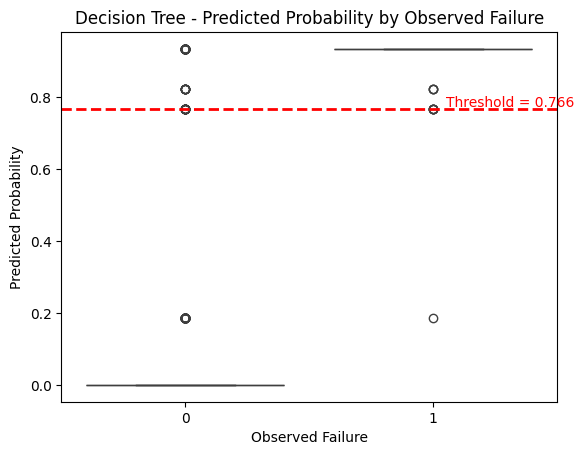

In [309]:
# Boxplot separation for Decision Tree

best_ks_decision_tree = find_threshold_by_ks(dt_results_decision_tree ["train"]["y_true"], dt_results_decision_tree["train"]["y_prob"])

sns.boxplot(
    data = dt_results_decision_tree["train"],
    x = "y_true",
    y = "y_prob"
)

plt.axhline(
    y=best_ks_decision_tree["threshold"],
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"KS Threshold = {best_ks_decision_tree["threshold"]:.3f}"
)

plt.text(
    x=1.05,
    y=best_ks_decision_tree["threshold"],
    s=f"Threshold = {best_ks_decision_tree["threshold"]:.3f}",
    color="red",
    va="bottom"
)

plt.xlabel("Observed Failure")
plt.ylabel("Predicted Probability")
plt.title("Decision Tree - Predicted Probability by Observed Failure")
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


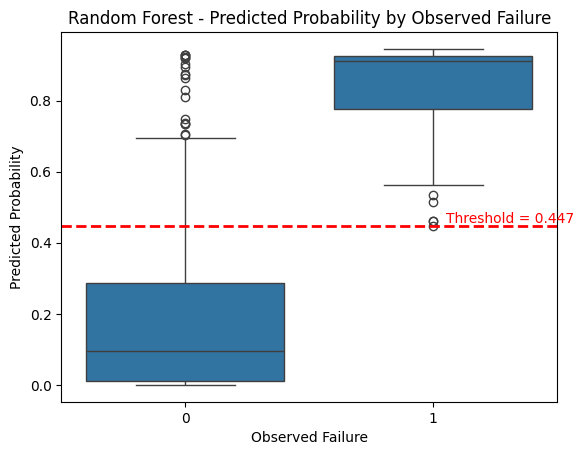

In [310]:
# Boxplot separation for Random Forest

best_ks_random_forest = find_threshold_by_ks(dt_results_random_forest["train"]["y_true"], dt_results_random_forest["train"]["y_prob"])

sns.boxplot(
    data = dt_results_random_forest["train"],
    x = "y_true",
    y = "y_prob"
)

plt.axhline(
    y=best_ks_random_forest["threshold"],
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"KS Threshold = {best_ks_random_forest["threshold"]:.3f}"
)

plt.text(
    x=1.05,
    y=best_ks_random_forest["threshold"],
    s=f"Threshold = {best_ks_random_forest["threshold"]:.3f}",
    color="red",
    va="bottom"
)

plt.xlabel("Observed Failure")
plt.ylabel("Predicted Probability")
plt.title("Random Forest - Predicted Probability by Observed Failure")
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


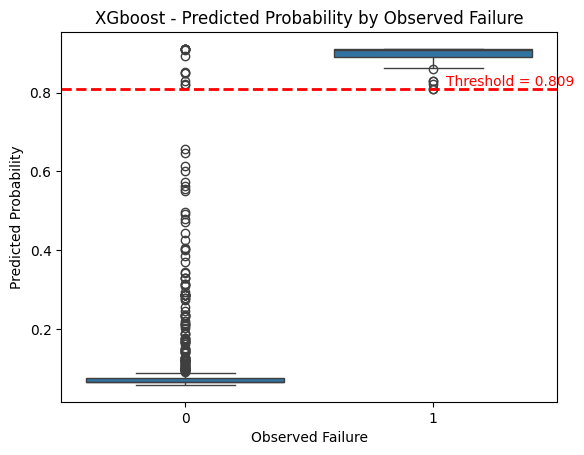

In [311]:
# Boxplot separation for Random Forest

best_ks_xgboost = find_threshold_by_ks(dt_results_xgboost["train"]["y_true"], dt_results_xgboost["train"]["y_prob"])

sns.boxplot(
    data = dt_results_xgboost["train"],
    x = "y_true",
    y = "y_prob"
)

plt.axhline(
    y=best_ks_xgboost["threshold"],
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"KS Threshold = {best_ks_xgboost["threshold"]:.3f}"
)

plt.text(
    x=1.05,
    y=best_ks_xgboost["threshold"],
    s=f"Threshold = {best_ks_xgboost["threshold"]:.3f}",
    color="red",
    va="bottom"
)

plt.xlabel("Observed Failure")
plt.ylabel("Predicted Probability")
plt.title("XGboost - Predicted Probability by Observed Failure")
plt.show()


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


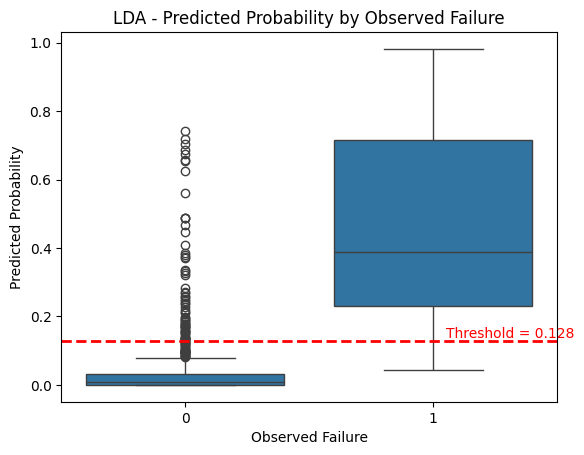

In [312]:
# Boxplot separation for LDA

best_ks_lda = find_threshold_by_ks(dt_results_lda ["train"]["y_true"], dt_results_lda["train"]["y_prob"])

sns.boxplot(
    data = dt_results_lda["train"],
    x = "y_true",
    y = "y_prob"
)

plt.axhline(
    y=best_ks_lda["threshold"],
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"KS Threshold = {best_ks_lda["threshold"]:.3f}"
)

plt.text(
    x=1.05,
    y=best_ks_lda["threshold"],
    s=f"Threshold = {best_ks_lda["threshold"]:.3f}",
    color="red",
    va="bottom"
)

plt.xlabel("Observed Failure")
plt.ylabel("Predicted Probability")
plt.title("LDA - Predicted Probability by Observed Failure")
plt.show()

In [313]:
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

def evaluate_model(
    y_true,
    y_prob,
    threshold
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return {
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [314]:
# Evaluation
decision_tree_metrics = evaluate_model(dt_results_decision_tree["test"]["y_true"], dt_results_decision_tree["test"]["y_prob"], best_ks_decision_tree["threshold"])
random_forest_metrics = evaluate_model(dt_results_random_forest["test"]["y_true"], dt_results_random_forest["test"]["y_prob"], best_ks_random_forest["threshold"])
xgboost_metrics = evaluate_model(dt_results_xgboost["test"]["y_true"], dt_results_xgboost["test"]["y_prob"], best_ks_xgboost["threshold"])
lda_metrics = evaluate_model(dt_results_lda["test"]["y_true"], dt_results_lda["test"]["y_prob"], best_ks_lda["threshold"])

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LDA"
    ],
    "F1": [
        decision_tree_metrics["F1"],
        random_forest_metrics["F1"],
        xgboost_metrics["F1"],
        lda_metrics["F1"]
    ],
    "Precision": [
        decision_tree_metrics["Precision"],
        random_forest_metrics["Precision"],
        xgboost_metrics["Precision"],
        lda_metrics["Precision"]
    ],
    "Recall": [
        decision_tree_metrics["Recall"],
        random_forest_metrics["Recall"],
        xgboost_metrics["Recall"],
        lda_metrics["Recall"]
    ],
    "TP": [
        decision_tree_metrics["TP"],
        random_forest_metrics["TP"],
        xgboost_metrics["TP"],
        lda_metrics["TP"]
    ],
    "FP": [
        decision_tree_metrics["FP"],
        random_forest_metrics["FP"],
        xgboost_metrics["FP"],
        lda_metrics["FP"]
    ],
    "FN": [
        decision_tree_metrics["FN"],
        random_forest_metrics["FN"],
        xgboost_metrics["FN"],
        lda_metrics["FN"]
    ],
    "TN": [
        decision_tree_metrics["TN"],
        random_forest_metrics["TN"],
        xgboost_metrics["TN"],
        lda_metrics["TN"]
    ]
})

comparison = comparison.sort_values(
    "F1",
    ascending=False
)

comparison

,Model,F1,Precision,Recall,TP,FP,FN,TN
3,LDA,1.000000,1.000000,1.000,8,0,0,12
1,Random Forest,0.941176,0.888889,1.000,8,1,0,11
0,Decision Tree,0.769231,1.000000,0.625,5,0,3,12
2,XGBoost,0.545455,1.000000,0.375,3,0,5,12


After evaluating the candidate models on the holdout test set, the Linear Discriminant Analysis (LDA) model achieved the best overall predictive performance.

Using the KS-based classification threshold, LDA outperformed the tree-based alternatives across the evaluated metrics, demonstrating a strong ability to distinguish between failure and non-failure observations. Notably, the model correctly classified all observations in the test set, resulting in no misclassifications during the final out-of-sample evaluation.

This result is particularly interesting given the simplicity of the LDA model compared to more complex machine learning approaches such as Random Forest and XGBoost. 

However, it is important to note that the test set contains only 20 observations. Therefore, although the results are highly encouraging, additional data would be required to fully validate the model's generalization capabilities under a broader range of operating conditions.

Overall, the findings indicate that LDA provides an excellent balance between predictive performance, interpretability, computational efficiency, and ease of deployment, making it the preferred model for this application.

#### Model Interpretability

To interpret the results, the driver importance of the best-performing model was evaluated. Since the best model was the Linear Discriminant Analysis (LDA), variable importance was derived from the coefficients of the estimated discriminant function.

Because the explanatory variables were standardized before model fitting, the coefficients are directly comparable across variables. Therefore, the relative importance of each variable was computed by taking the absolute value of its coefficient and dividing it by the sum of the absolute coefficients across all variables.

This approach provides an interpretable measure of how much each variable contributes to the linear discriminant function used to separate failure and non-failure observations.



In [315]:
importance = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": dt_results_lda["best_model"]["lda"].coef_[0]
})

importance["Importance"] = np.abs(
    importance["Coefficient"]
)/np.sum(np.abs(
    importance["Coefficient"]
))

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance

,Variable,Coefficient,Importance
3,VibrationY,1.179126,0.325659
5,Frequency,0.744203,0.205539
4,VibrationZ,0.514966,0.142227
1,Pressure,0.453857,0.125349
2,VibrationX,0.419431,0.115841
0,Temperature,0.309157,0.085385


By evaluating the variable importance rankings, we observe that **VibrationY** is the most influential predictor, accounting for approximately **32.5%** of the model's discriminatory power. The second most important variable is **Frequency**, contributing **20.5%**, followed by **VibrationZ** and **Pressure**.

The prominent role of VibrationY was expected and is consistent with the previous bivariate analysis, where this variable exhibited the highest KS statistic and therefore the strongest individual discriminatory power between failure and non-failure observations.

The importance assigned to Frequency, however, is particularly interesting. Although Frequency did not emerge as the strongest predictor in the univariate analysis, it became one of the most influential variables in the multivariate model. This finding supports the hypothesis raised during the exploratory analysis that Frequency may be highly informative within specific regions of the feature space rather than across its entire operating range.

More broadly, these results suggest that equipment failures are not driven by isolated sensor measurements but rather by specific combinations of operating conditions. In other words, failure events appear to occur within particular regions of the multidimensional feature space, where the interaction among variables becomes more informative than any individual variable considered independently.

This observation may also explain the strong performance achieved by the LDA model. By constructing an optimized linear discriminant space that maximizes the separation between failure and non-failure observations, LDA was able to effectively capture these multivariate relationships and identify the regions most strongly associated with equipment failures.
